<a href="https://colab.research.google.com/github/IMPERIUMSIXTH/JupyterNotebooks/blob/main/Percerptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install celluloid
!pip install scienceplots

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# %matplotlib ipympl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from celluloid import Camera
import scienceplots
from IPython.display import Image

np.random.seed(0)
plt.style.use(["science", "no-latex"])

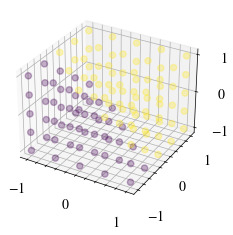

In [2]:
def generate_dataset(dims, normal_vector):
    # create 3D grid of points
    points = np.linspace(-1, 1, dims)
    X, Y, Z = np.meshgrid(points, points, points)

    # features are the x, y, z coordinates
    features = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))

    # labels are the side each point is on the hyperplane
    distances = np.dot(features, normal_vector)
    labels = np.where(distances >= 0, 1, -1)
    return X, Y, Z, features, labels

# normalized normal vector
target_normal_vector = np.array([1.0, 1.0, 1.0])
target_normal_vector = target_normal_vector / np.linalg.norm(target_normal_vector)

scaling = 5
X, Y, Z, features, labels = generate_dataset(scaling, target_normal_vector)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# plot the points
ax.scatter(features[:,0], features[:,1], features[:,2], marker='o', alpha=0.3, c=labels)

Text(0.5, 0.92, 'Hyperplane')

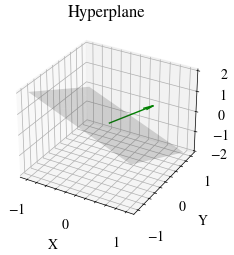

In [3]:
def generate_hyperplane(scaling, normal_vector):
    # create 2D points
    points = np.linspace(-1, 1, scaling)
    xx, yy = np.meshgrid(points, points)

    # the z value is the defined by the hyperplane
    zz = -(normal_vector[0] * xx + normal_vector[1] * yy) / normal_vector[2]
    return xx, yy, zz

xx, yy, zz = generate_hyperplane(scaling, target_normal_vector)

# visualize the hyperplane
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# plot the hyperplane defined by the normal vector
ax.plot_surface(xx, yy, zz, alpha=0.2, color="gray")
ax.quiver(
    0,
    0,
    0,
    target_normal_vector[0],
    target_normal_vector[1],
    target_normal_vector[2],
    color="green",
    length=1,
    arrow_length_ratio=0.2,
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Hyperplane")

In [4]:
def hinge_loss(w, x, b, y):
    return max(0.0, -y * (np.dot(w, x) + b))

In [5]:
def hinge_loss_db(w, x, b, y):
    if y * (np.dot(w, x) + b) <= 0.0:
        return -y
    return 0

In [6]:
def hinge_loss_dw(w, x, b, y):
    if y * (np.dot(w, x) + b) <= 0.0:
        return -y * x
    return np.zeros_like(x)

In [7]:
def create_plots():
    fig, ax = plt.subplots(2, 3, figsize=(16 / 9.0 * 4, 4 * 1), layout="constrained")
    fig.suptitle("Perceptron")

    ax[0, 0].set_xlabel("Epoch", fontweight="normal")
    ax[0, 0].set_ylabel("Error", fontweight="normal")
    ax[0, 0].set_title("Hinge Loss")

    ax[1, 0].set_xlabel("Z, Distance to Hyperplane", fontweight="normal")
    ax[1, 0].set_ylabel("", fontweight="normal")
    ax[1, 0].set_title("Linear Transformation")

    ax[0, 1].axis("off")
    ax[0, 2].axis("off")
    ax[1, 1].axis("off")
    ax[1, 2].axis("off")

    ax[1, 2] = fig.add_subplot(1, 2, 2, projection="3d")
    ax[1, 2].set_xlabel("X")
    ax[1, 2].set_ylabel("Y")
    ax[1, 2].set_zlabel("Z")
    ax[1, 2].set_title("Hyperplane Decision Boundary")
    ax[1, 2].view_init(20, -35)
    ax[1, 2].set_xlim(-1, 1)
    ax[1, 2].set_ylim(-1, 1)
    ax[1, 2].set_zlim(-1, 1)

    camera = Camera(fig)
    return ax[0, 0], ax[1, 0], ax[1, 2], camera


def plot_graphs(
    ax0,
    ax1,
    ax2,
    idx,
    visible_err,
    err_idx,
    errors,
    scaling,
    target_normal_vector,
    predictions,
    features,
    labels,
    weights,
):
    ax0.plot(
        err_idx[visible_err][: idx + 1],
        errors[visible_err][: idx + 1],
        color="red",
    )

    # Ground truth
    xx_target, yy_target, zz_target = generate_hyperplane(scaling, target_normal_vector)
    ground_truth_legend = ax2.plot_surface(
        xx_target,
        yy_target,
        zz_target,
        color="red",
        alpha=0.2,
        label="Ground Truth",
    )
    ax2.quiver(
        0,
        0,
        0,
        target_normal_vector[0],
        target_normal_vector[1],
        target_normal_vector[2],
        color="red",
        length=1,
        arrow_length_ratio=0.1,
    )

    # Perceptron predictions using 2D graph to show linear transformation
    def generate_colors(arr):
        return ["green" if d >= 0 else "orange" for d in arr]

    ground_truth_colors = generate_colors(labels)
    ax1.scatter(
        predictions,
        np.zeros(predictions.shape),
        c=ground_truth_colors,
        marker="o",
        alpha=0.3,
    )

    # Perceptron predictions using 3D graph to show hyperplane
    predictions_colors = generate_colors(predictions)
    predictions_norm = np.maximum(1 - np.exp(-(predictions**2)), 0.2)

    ax2.scatter(
        features[:, 0],
        features[:, 1],
        features[:, 2],
        c=predictions_colors,
        marker="o",
        alpha=predictions_norm,
    )

    xx, yy, zz = generate_hyperplane(scaling, weights)
    predictions_legend = ax2.plot_surface(
        xx,
        yy,
        zz,
        color="blue",
        alpha=0.2,
        label="Prediction",
    )
    ax2.quiver(
        0,
        0,
        0,
        weights[0],
        weights[1],
        weights[2],
        color="blue",
        length=1,
        arrow_length_ratio=0.1,
    )

    # Legend
    ax2.legend(
        (ground_truth_legend, predictions_legend),
        ("Ground Truth", "Predictions"),
        loc="upper left",
    )

In [8]:
def gradient_descent(weights, x, bias, y, learning_rate):
    weights = weights - learning_rate * hinge_loss_dw(weights, x, bias, y)
    bias = bias - learning_rate * hinge_loss_db(weights, x, bias, y)

    return weights, bias

In [9]:
def fit(
    weights,
    bias,
    target_normal_vector,
    features,
    labels,
    X,
    Y,
    Z,
    scaling,
    epochs,
    learning_rate,
    optimizer,
    output_filename,
):
    err_idx = np.arange(1, epochs + 1)
    errors = np.full(epochs, -1)
    ax0, ax1, ax2, camera = create_plots()

    for idx in range(epochs):
        error = 0
        predictions = np.array([])

        for x, y in zip(features, labels):
            # Forward Propagation
            output = np.dot(weights, x) + bias

            predictions = np.append(predictions, output)

            # Store Error
            error += hinge_loss(weights, x, bias, y)

            # Gradient Descent
            weights, bias = optimizer(weights, x, bias, y, learning_rate)

        error /= len(X)
        weights = weights / np.linalg.norm(weights)

        if (
            idx < 5
            or (idx < 15 and idx % 2 == 0)
            or (idx <= 50 and idx % 10 == 0)
            or (idx <= 1000 and idx % 20 == 0)
            or idx % 250 == 0
        ):

            print(f"epoch: {idx}, MSE: {error}")

            # Plot MSE
            errors[idx] = error
            visible_err = errors != -1

            plot_graphs(
                ax0,
                ax1,
                ax2,
                idx,
                visible_err,
                err_idx,
                errors,
                scaling,
                target_normal_vector,
                predictions,
                features,
                labels,
                weights,
            )

            camera.snap()

    animation = camera.animate()
    animation.save(output_filename, writer="pillow")
    plt.show()

In [10]:
weights = np.array([1.0, -1.0, -1.0])
weights = weights / np.linalg.norm(weights)

bias = 0

epoch: 0, MSE: 9.314269414709884
epoch: 1, MSE: 9.227024830601328
epoch: 2, MSE: 9.145087443313994
epoch: 3, MSE: 9.054781136556876
epoch: 4, MSE: 8.960407022428585
epoch: 6, MSE: 8.758853058777223
epoch: 8, MSE: 8.53921460232333
epoch: 10, MSE: 8.301374396907338
epoch: 12, MSE: 8.08268967439665
epoch: 14, MSE: 7.848010649913292
epoch: 20, MSE: 7.2399656649458395
epoch: 30, MSE: 6.264254344109916
epoch: 40, MSE: 5.307156953825982
epoch: 50, MSE: 4.404348110031334
epoch: 60, MSE: 3.583744302061389
epoch: 80, MSE: 2.0340687540122784
epoch: 100, MSE: 0.9393759997635176
epoch: 120, MSE: 0.3544588382632633
epoch: 140, MSE: 0.12744345824321832
epoch: 160, MSE: 0.018715050957434115
epoch: 180, MSE: 0.0
epoch: 200, MSE: 0.0
epoch: 220, MSE: 0.0
epoch: 240, MSE: 0.0
epoch: 250, MSE: 0.0
epoch: 260, MSE: 0.0
epoch: 280, MSE: 0.0
epoch: 300, MSE: 0.0


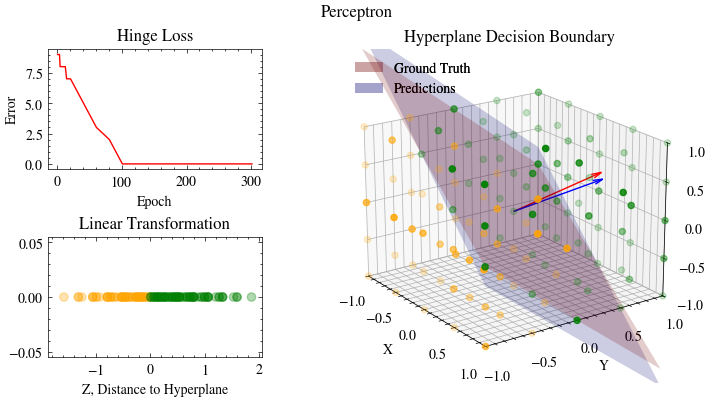

In [11]:
epochs = 301
learning_rate = 0.0005

output_filename = "perceptron.gif"
fit(
    weights,
    bias,
    target_normal_vector,
    features,
    labels,
    X,
    Y,
    Z,
    scaling,
    epochs,
    learning_rate,
    gradient_descent,
    output_filename,
)

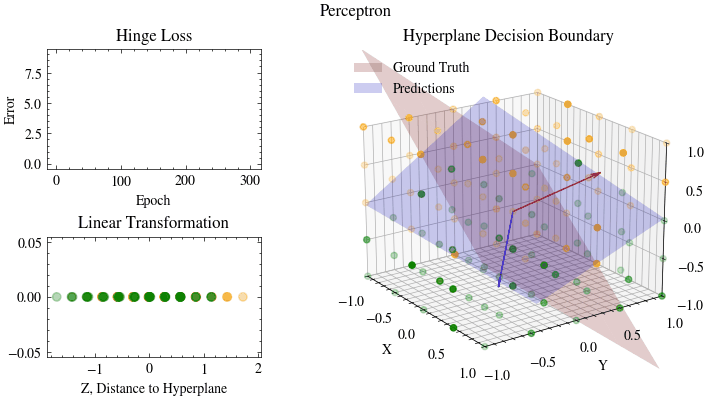

In [12]:
Image(filename=output_filename)